In [32]:
from sklearnex import patch_sklearn
import sys
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
sys.path.append( '../../phenotyping/')
from phenotyping_utils import generate_anndata_from_ark_analysis,umap,normalise_by_group
import random
import sklearn
from xgboost import XGBClassifier
import numpy as np

In [5]:
!ls ../../phenotyping/

__pycache__  create_adata.py  phenograph  phenotyping_utils.py	pixie


In [289]:
reload = True
file_name = '../../phenotyping/pixie/data/sc_protein_by_patient.h5ad'
if reload:
    adata = sc.read_h5ad(file_name)
else:
    base_dir = '../../../'
    cell_table_path=base_dir+'segmentation/cell_table_Denoised/cell_table_size_normalized_cell_labels.csv'
    biosamples_path=base_dir+'IMC_data/ExtraDocs/processed_response_enR.csv'
    
    adata = generate_anndata_from_ark_analysis(cell_table_path=cell_table_path,biosamples_path=biosamples_path,normalise_key='Patient')
    #consider whether to overwrite passing save = True
    #adata.write(file_name)
#adata = adata[adata.obs.qc_pass==True]
adata = normalise_by_group(adata,group_key='Patient',inplace=True,force_normalisation=True)
core = adata[adata.obs['SAMPLE_TYPE_(CORE/RESECTION)']=='CORE',~adata.var.index.isin(['Carboplatin','DNA1','DNA2'])]

#X = core.layers['normalised'].copy() #adata.obsm['X_pca']


data seem already normalised
Normalising anyway


In [290]:
X = core.X
#X = sklearn.preprocessing.StandardScaler().fit_transform(core.X)

y =  core.obs.Response.map({'Non-Responder':0,'pCR':1}).values

patients = core.obs.Patient.drop_duplicates()
#sample 30 percent of the Responder and non responder group
patients = core.obs[['Patient','Response']].drop_duplicates().groupby('Response',observed = True).Patient.apply(
    lambda x: x.sample(frac=0.30)
)
cond = core.obs.Patient.isin(patients)
#split train/tesgt according to acquisition_Ids 
test_acq_ids = random.sample(core.obs.acquisition_ID.drop_duplicates().to_list(),int(len(core.obs.acquisition_ID.drop_duplicates())*0.33))
#cond = core.obs.acquisition_ID.isin(test_acq_ids)

X_train,y_train = X[~cond],y[~cond]
X_test,y_test = X[cond],y[cond]



In [281]:
cond

index
0          False
1          False
2          False
3          False
4          False
           ...  
3589920     True
3589921     True
3589922     True
3589923     True
3589924     True
Name: Patient, Length: 2545779, dtype: bool

In [265]:
y_train

[], Categories (2, int64): [0, 1]

<Axes: >

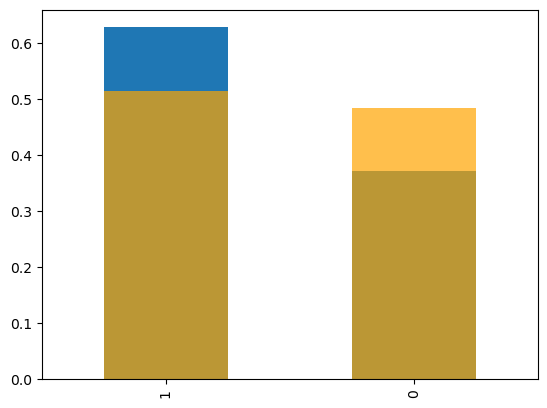

In [291]:
patients
pd.Series(y_train).value_counts(normalize = True).plot(kind = 'bar')
pd.Series(y_test).value_counts(normalize = True).plot(kind = 'bar',color = 'orange',alpha = 0.7)

In [292]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score, f1_score
def compute_scores_train(y_train, y_pred_train, y_test, y_pred_test):
	"""
	Computes various evaluation scores for both training and test sets.

	Args:
		y_train (list or numpy.ndarray): True labels for training set.
		y_pred_train (list or numpy.ndarray): Predicted labels for training set.
		y_test (list or numpy.ndarray): True labels for test set.
		y_pred_test (list or numpy.ndarray): Predicted labels for test set.

	Returns:
		metrics (dict): Dictionary containing evaluation metrics for both sets.
	"""
	accuracy_train = accuracy_score(y_train, y_pred_train)
	balanced_accuracy_train = balanced_accuracy_score(y_train, y_pred_train)
	auc_train = roc_auc_score(y_train, y_pred_train)
	f1_train = f1_score(y_train, y_pred_train)

	accuracy_test = accuracy_score(y_test, y_pred_test)
	balanced_accuracy_test = balanced_accuracy_score(y_test, y_pred_test)
	auc_test = roc_auc_score(y_test, y_pred_test)
	f1_test = f1_score(y_test, y_pred_test)
	metrics = {
			'Accuracy Train': accuracy_train,
			'Balanced_Accuracy Train': balanced_accuracy_train,
			'Accuracy Test': accuracy_test,
			'Balanced_Accuracy Test': balanced_accuracy_test,
			'AUC Train': auc_train,
			'AUC Test': auc_test,
			'F1 Score Train': f1_train,
			'F1 Score Test': f1_test,			
	}
	return metrics




In [286]:
gaussian_noise = np.random.normal(0, 0.05, X_train.shape)
#X_train+gaussian_noise
X_train = np.concatenate((X_train,X_train+gaussian_noise),axis = 0)
y_train = np.concatenate((y_train,y_train))


In [301]:

boosting = XGBClassifier(n_estimators=15, max_depth=3, learning_rate=.2, objective='binary:logistic', device="cuda",min_split_loss = 1,reg_lambda = 10,sampling_method = 'gradient_based')
boosting.fit(X_train,y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda', early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, min_split_loss=1, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=15,
              n_jobs=None, num_parallel_tree=None, ...)

In [302]:
compute_scores_train(y_train, boosting.predict(X_train), y_test, boosting.predict(X_test))

{'Accuracy Train': 0.781396562264187,
 'Balanced_Accuracy Train': 0.7329171691644181,
 'Accuracy Test': 0.4786447584363799,
 'Balanced_Accuracy Test': 0.47016164565306606,
 'AUC Train': 0.7329171691644181,
 'AUC Test': 0.47016164565306606,
 'F1 Score Train': 0.841246106189127,
 'F1 Score Test': 0.5994953505196478}

In [303]:
def aggregate_logratio(p,acq_ids):
    logratio = pd.DataFrame(np.log(p/(1-p)),columns = ['logratio'])
    logratio['acquisition_ID'] = acq_ids
    #logratio['Patient'] = core.obs.loc[~cond].Patient.to_numpy()
    logratio= logratio[['logratio','acquisition_ID']].groupby(by = 'acquisition_ID').median()
    return logratio
def aggregate_prediction(model,X_train,X_test,y_train,y_test):

    p = boosting.predict_proba(X_train)[:,1]
    logratio_train = aggregate_logratio(p,acq_ids = core.obs.loc[~cond].acquisition_ID.to_numpy())
    y_hat_train = logratio_train.map(lambda x:1/(1+np.exp(-x)))
    p = boosting.predict_proba(X_test)[:,1]
    logratio_test = aggregate_logratio(p,acq_ids = core.obs.loc[cond].acquisition_ID.to_numpy())
    y_hat_test = logratio_test.map(lambda x:1/(1+np.exp(-x)))
    #now aggregate the target values per acquisition
    y = pd.DataFrame(y_train,columns = ['label'])
    y['acquisition_ID'] = core.obs.loc[~cond].acquisition_ID.to_numpy()
    y_train = y[['label','acquisition_ID']].drop_duplicates()['label']
    y = pd.DataFrame(y_test,columns = ['label'])
    y['acquisition_ID'] = core.obs.loc[cond].acquisition_ID.to_numpy()
    y_test = y[['label','acquisition_ID']].drop_duplicates()['label']
    return compute_scores_train(y_train=y_train,y_pred_train=y_hat_train>0.5,y_pred_test=y_hat_test>0.5,y_test=y_test)

aggregate_prediction(boosting,X_train,X_test,y_train,y_test)

{'Accuracy Train': 0.7610921501706485,
 'Balanced_Accuracy Train': 0.7261191901910464,
 'Accuracy Test': 0.48201438848920863,
 'Balanced_Accuracy Test': 0.4746271748135874,
 'AUC Train': 0.7261191901910464,
 'AUC Test': 0.4746271748135874,
 'F1 Score Train': 0.8232323232323232,
 'F1 Score Test': 0.6170212765957447}

(array([0.60920863, 0.49197671, 0.63066865, 0.48535981, 0.78689299,
        1.35426152, 1.23622519, 1.10165327, 1.76480668, 1.58694444]),
 array([3.48605245e-04, 9.98709202e-02, 1.99393228e-01, 2.98915535e-01,
        3.98437858e-01, 4.97960180e-01, 5.97482502e-01, 6.97004795e-01,
        7.96527088e-01, 8.96049440e-01, 9.95571733e-01]),
 <BarContainer object of 10 artists>)

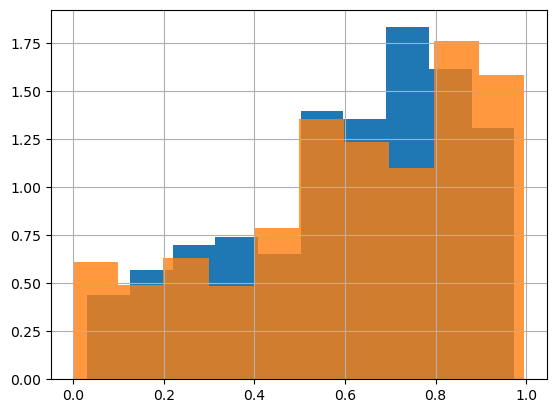

In [12]:
p = boosting.predict_proba(X_train)[:,1]
logratio_train = aggregate_logratio(p,acq_ids = core.obs.loc[~cond].acquisition_ID.to_numpy())
logratio_train.logratio.map(lambda x:1/(1+np.exp(-x))).hist(density = True)
plt.hist(p,density = True,alpha = 0.8)

(array([0.54017665, 0.6481545 , 0.71041392, 0.56867642, 0.90772225,
        1.55605335, 1.12395649, 0.86142857, 1.85082845, 1.29775636]),
 array([0.00204621, 0.10139876, 0.2007513 , 0.30010387, 0.39945641,
        0.49880898, 0.59816152, 0.69751406, 0.79686666, 0.89621919,
        0.99557173]),
 <BarContainer object of 10 artists>)

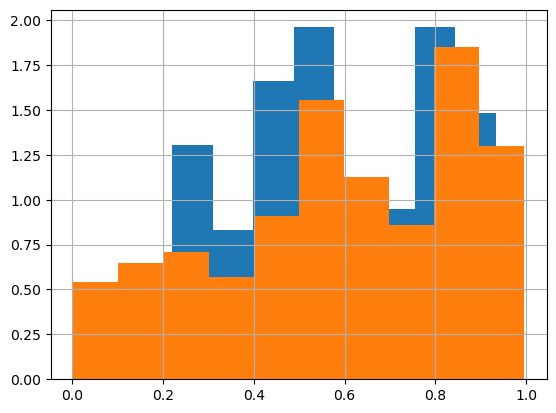

In [13]:

p = boosting.predict_proba(X_test)[:,1]
logratio_test = aggregate_logratio(p,acq_ids = core.obs.loc[cond].acquisition_ID.to_numpy())

logratio_test.logratio.map(lambda x:1/(1+np.exp(-x))).hist(density = True)
logratio_test.logratio
plt.hist(p,density = True)

In [142]:
clf = Log(n_estimators=2, max_depth=3, learning_rate=1, objective='binary:logistic', device="cuda")
boosting.fit(X_train,y_train)


0          0
5850       0
8435       0
9488       0
15308      0
          ..
1650493    1
1658084    1
1667902    1
1677158    1
1681090    1
Name: label, Length: 296, dtype: category
Categories (2, int64): [0, 1]

In [285]:
X_train.shape

(1748441, 35)

array([-0.3531494,  0.3531494], dtype=float32)

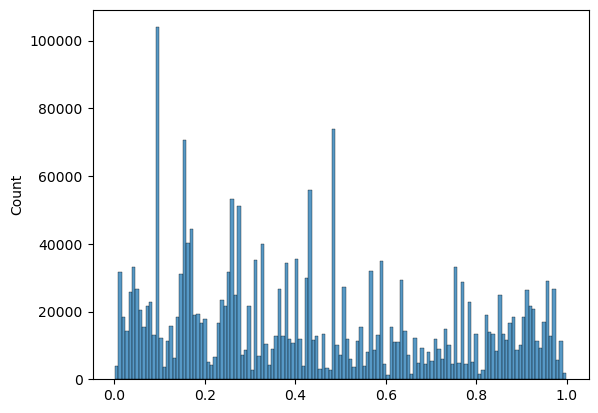

In [326]:
sns.histplot(boosting.predict_proba(X_train)[:,0])
p = boosting.predict_proba(X_train)
np.mean(np.log(p/(1-p)),axis = 0)

In [25]:
import shap


In [26]:

explainer = shap.GPUTreeExplainer(boosting,X_train,feature_names= core.var.index)
shap_values = explainer(X_test)


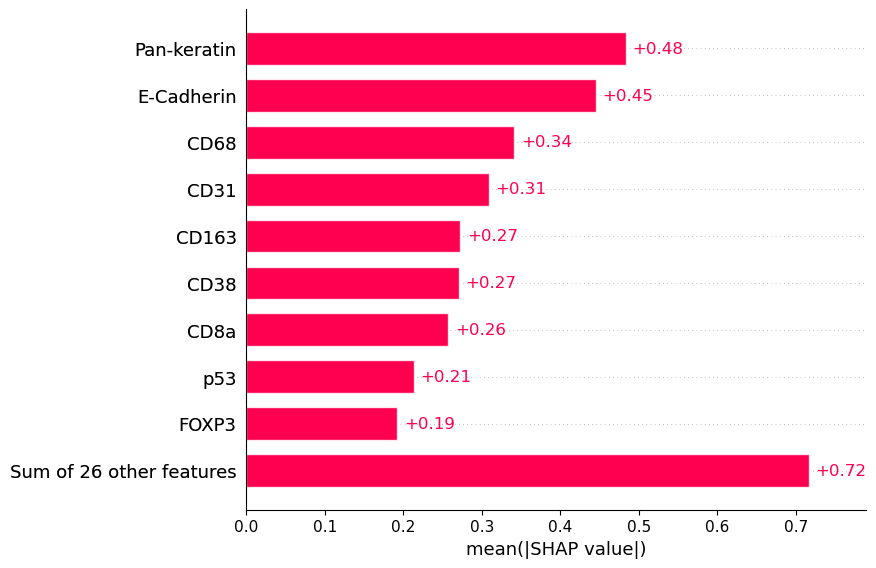

In [76]:
shap.plots.bar(shap_values,max_display=10)

In [88]:
explainer.expected_value
len(shap_values[0].feature_names)

35

AssertionError: Feature and SHAP matrices must have the same number of rows!

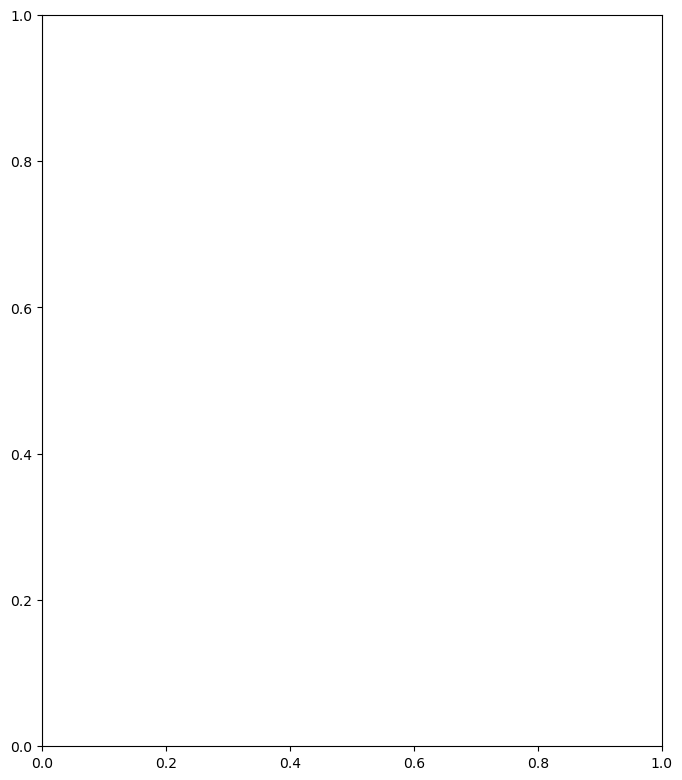

In [31]:
shap.sample(shap_values,1000).values.shape,len(shap_values.feature_names)
shap.summary_plot(shap_values[:1],show=False)


AssertionError: Feature and SHAP matrices must have the same number of rows!

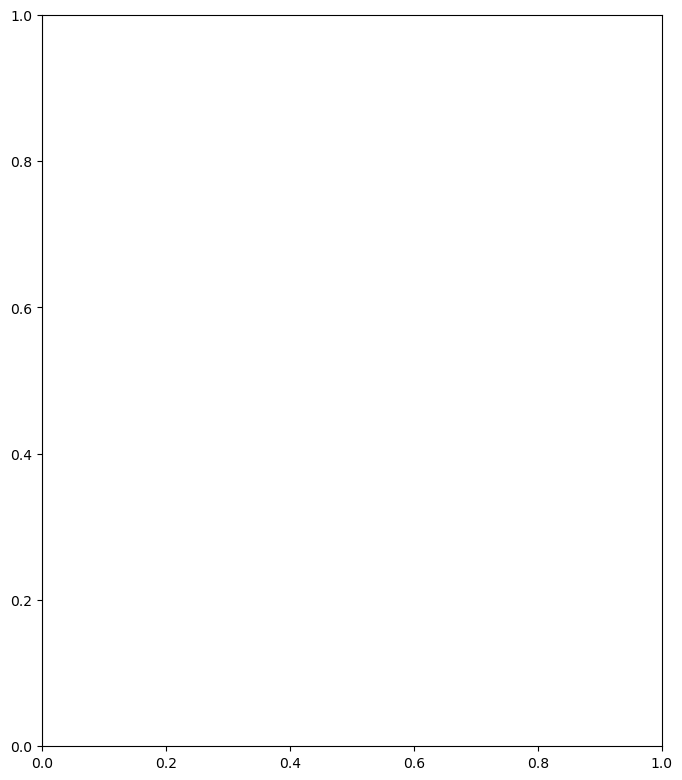

In [27]:
shap.summary_plot(shap.sample(shap_values,1000),show=False)


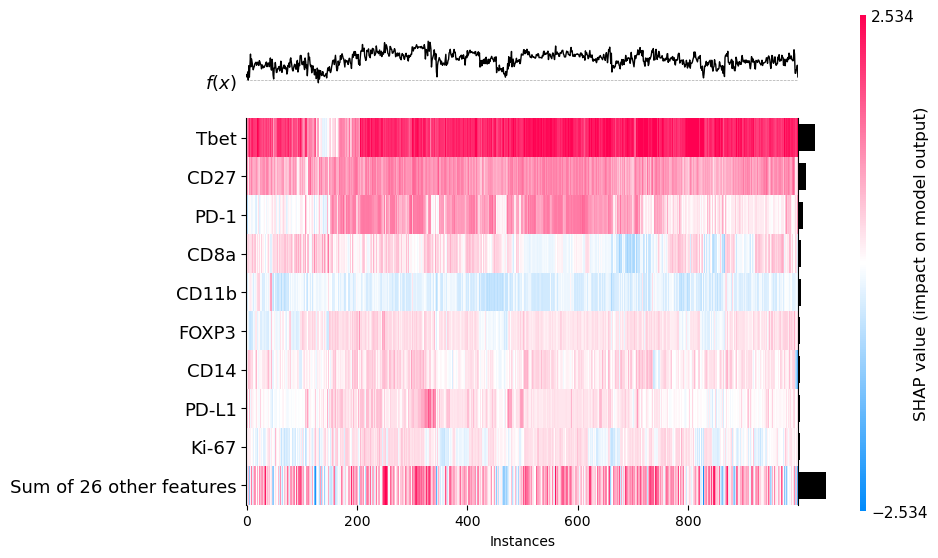

In [40]:
shap.plots.heatmap(shap_values[-1000:])

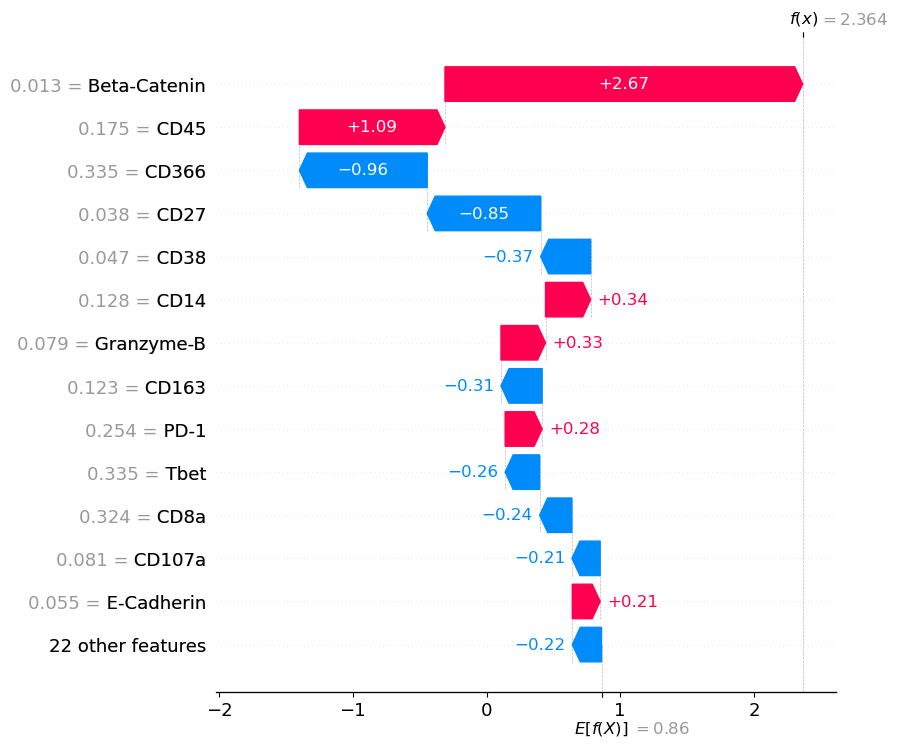

In [38]:
shap.plots.waterfall(shap_values[0], max_display=14)


In [46]:
p = boosting.predict_proba(X_train)
np.mean(np.log(p/(1-p)),axis = 0)

array([-0.8215882 ,  0.82158816], dtype=float32)

/tmp/ipykernel_1082734/2459609185.py:2: RuntimeWarning: divide by zero encountered in divide
  plt.plot(t,np.log(t/(1-t)))
/tmp/ipykernel_1082734/2459609185.py:2: RuntimeWarning: divide by zero encountered in log
  plt.plot(t,np.log(t/(1-t)))


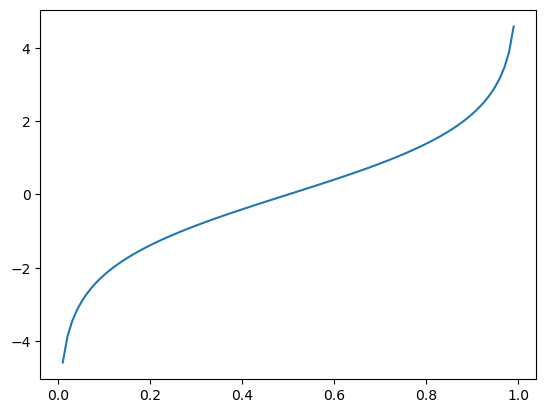

In [185]:
t = np.linspace(0,1,100)
plt.plot(t,np.log(t/(1-t)))